In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/RATE_FP_Project")
DATA_DIR = BASE_DIR / "data" / "jdt"

print("Data directory exists:", DATA_DIR.exists())
print("Files:")
for f in DATA_DIR.iterdir():
    print(f.name)

Data directory exists: True
Files:
change-metrics.csv
single-version-ck-oo.csv
biweekly-ck-values.zip
biweekly-oo-values.zip
biweekly-ck-values
biweekly-oo-values


In [ ]:
import zipfile
from pathlib import Path

for file in DATA_DIR.iterdir():
    if file.suffix.lower() == ".zip":
        extract_dir = DATA_DIR / file.stem
        extract_dir.mkdir(exist_ok=True)

        with zipfile.ZipFile(file, "r") as zip_ref:
            zip_ref.extractall(extract_dir)

        print(f"Extracted: {file.name} -> {extract_dir}")

Extracted: biweekly-ck-values.zip -> /content/drive/MyDrive/RATE_FP_Project/data/jdt/biweekly-ck-values
Extracted: biweekly-oo-values.zip -> /content/drive/MyDrive/RATE_FP_Project/data/jdt/biweekly-oo-values


In [ ]:
for path in DATA_DIR.rglob("*"):
    if path.is_file():
        print(path.relative_to(DATA_DIR))

change-metrics.csv
single-version-ck-oo.csv
biweekly-ck-values.zip
biweekly-oo-values.zip
biweekly-ck-values/biweekly-ck-values/eclipse-class-cbo.csv
biweekly-ck-values/biweekly-ck-values/eclipse-class-dit.csv
biweekly-ck-values/biweekly-ck-values/eclipse-class-lcom.csv
biweekly-ck-values/biweekly-ck-values/eclipse-class-noc.csv
biweekly-ck-values/biweekly-ck-values/eclipse-class-rfc.csv
biweekly-ck-values/biweekly-ck-values/eclipse-class-wmc.csv
biweekly-oo-values/biweekly-oo-values/eclipse-class-fanIn.csv
biweekly-oo-values/biweekly-oo-values/eclipse-class-fanOut.csv
biweekly-oo-values/biweekly-oo-values/eclipse-class-numberOfAttributes.csv
biweekly-oo-values/biweekly-oo-values/eclipse-class-numberOfAttributesInherited.csv
biweekly-oo-values/biweekly-oo-values/eclipse-class-numberOfLinesOfCode.csv
biweekly-oo-values/biweekly-oo-values/eclipse-class-numberOfMethods.csv
biweekly-oo-values/biweekly-oo-values/eclipse-class-numberOfMethodsInherited.csv
biweekly-oo-values/biweekly-oo-value

In [ ]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn openpyxl xlrd

In [ ]:
import pandas as pd
from pathlib import Path

def load_table(file_path):
    suffix = file_path.suffix.lower()

    if suffix in [".csv"]:
        return pd.read_csv(file_path)

    elif suffix in [".xlsx"]:
        return pd.read_excel(file_path, engine="openpyxl")

    elif suffix in [".xls"]:
        return pd.read_excel(file_path)

    elif suffix in [".txt", ".dat"]:
        try:
            return pd.read_csv(file_path, sep=None, engine="python")
        except Exception:
            return pd.read_csv(file_path, sep="\t")

    elif suffix in [".arff"]:
        from scipy.io import arff
        data, meta = arff.loadarff(file_path)
        df = pd.DataFrame(data)
        for col in df.select_dtypes([object]).columns:
            df[col] = df[col].str.decode("utf-8")
        return df

    else:
        return None


tables = {}

for file in DATA_DIR.rglob("*"):
    if file.is_file() and file.suffix.lower() in [".csv", ".xlsx", ".xls", ".txt", ".dat", ".arff"]:
        try:
            df = load_table(file)
            if df is not None:
                tables[str(file.relative_to(DATA_DIR))] = df
                print("\n" + "="*80)
                print("FILE:", file.relative_to(DATA_DIR))
                print("Shape:", df.shape)
                print("Columns:")
                print(list(df.columns))
                print(df.head())
        except Exception as e:
            print("Could not read:", file.relative_to(DATA_DIR), "| Error:", e)


FILE: change-metrics.csv
Shape: (997, 1)
Columns:
['classname ; numberOfVersionsUntil: ; numberOfFixesUntil: ; numberOfRefactoringsUntil: ; numberOfAuthorsUntil: ; linesAddedUntil: ; maxLinesAddedUntil: ; avgLinesAddedUntil: ; linesRemovedUntil: ; maxLinesRemovedUntil: ; avgLinesRemovedUntil: ; codeChurnUntil: ; maxCodeChurnUntil: ; avgCodeChurnUntil: ; ageWithRespectTo: ; weightedAgeWithRespectTo: ; bugs ; nonTrivialBugs ; majorBugs ; criticalBugs ; highPriorityBugs ; ']
  classname ; numberOfVersionsUntil: ; numberOfFixesUntil: ; numberOfRefactoringsUntil: ; numberOfAuthorsUntil: ; linesAddedUntil: ; maxLinesAddedUntil: ; avgLinesAddedUntil: ; linesRemovedUntil: ; maxLinesRemovedUntil: ; avgLinesRemovedUntil: ; codeChurnUntil: ; maxCodeChurnUntil: ; avgCodeChurnUntil: ; ageWithRespectTo: ; weightedAgeWithRespectTo: ; bugs ; nonTrivialBugs ; majorBugs ; criticalBugs ; highPriorityBugs ; 
0  org::eclipse::jdt::internal::core::search::ind...                                             

In [ ]:
for name, df in tables.items():
    print("\n" + "="*80)
    print("FILE:", name)
    defect_cols = [
        col for col in df.columns
        if any(key in str(col).lower() for key in ["bug", "defect", "fault", "post", "severity", "priority"])
    ]
    print("Possible target columns:", defect_cols)


FILE: change-metrics.csv
Possible target columns: ['classname ; numberOfVersionsUntil: ; numberOfFixesUntil: ; numberOfRefactoringsUntil: ; numberOfAuthorsUntil: ; linesAddedUntil: ; maxLinesAddedUntil: ; avgLinesAddedUntil: ; linesRemovedUntil: ; maxLinesRemovedUntil: ; avgLinesRemovedUntil: ; codeChurnUntil: ; maxCodeChurnUntil: ; avgCodeChurnUntil: ; ageWithRespectTo: ; weightedAgeWithRespectTo: ; bugs ; nonTrivialBugs ; majorBugs ; criticalBugs ; highPriorityBugs ; ']

FILE: single-version-ck-oo.csv
Possible target columns: ['classname ; cbo ; dit ; fanIn ; fanOut ; lcom ; noc ; numberOfAttributes ; numberOfAttributesInherited ; numberOfLinesOfCode ; numberOfMethods ; numberOfMethodsInherited ; numberOfPrivateAttributes ; numberOfPrivateMethods ; numberOfPublicAttributes ; numberOfPublicMethods ; rfc ; wmc ; bugs ; nonTrivialBugs ; majorBugs ; criticalBugs ; highPriorityBugs ; ']

FILE: biweekly-ck-values/biweekly-ck-values/eclipse-class-cbo.csv
Possible target columns: []

FILE: 

In [ ]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/RATE_FP_Project")
DATA_DIR = BASE_DIR / "data" / "jdt"

change_path = DATA_DIR / "change-metrics.csv"
ckoo_path = DATA_DIR / "single-version-ck-oo.csv"

def clean_column_names(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(":", "", regex=False)
        .str.replace(" ", "_", regex=False)
    )
    return df

def load_semicolon_csv(path):
    df = pd.read_csv(path, sep=";", engine="python")
    df = df.dropna(axis=1, how="all")      # remove empty trailing column
    df = clean_column_names(df)
    return df

change_df = load_semicolon_csv(change_path)
ckoo_df = load_semicolon_csv(ckoo_path)

print("Change metrics shape:", change_df.shape)
print(change_df.columns.tolist())
display(change_df.head())

print("\nCK + OO metrics shape:", ckoo_df.shape)
print(ckoo_df.columns.tolist())
display(ckoo_df.head())

Change metrics shape: (997, 22)
['classname', 'numberOfVersionsUntil', 'numberOfFixesUntil', 'numberOfRefactoringsUntil', 'numberOfAuthorsUntil', 'linesAddedUntil', 'maxLinesAddedUntil', 'avgLinesAddedUntil', 'linesRemovedUntil', 'maxLinesRemovedUntil', 'avgLinesRemovedUntil', 'codeChurnUntil', 'maxCodeChurnUntil', 'avgCodeChurnUntil', 'ageWithRespectTo', 'weightedAgeWithRespectTo', 'bugs', 'nonTrivialBugs', 'majorBugs', 'criticalBugs', 'highPriorityBugs', '']


,classname,numberOfVersionsUntil,numberOfFixesUntil,numberOfRefactoringsUntil,numberOfAuthorsUntil,linesAddedUntil,maxLinesAddedUntil,avgLinesAddedUntil,linesRemovedUntil,maxLinesRemovedUntil,...,maxCodeChurnUntil,avgCodeChurnUntil,ageWithRespectTo,weightedAgeWithRespectTo,bugs,nonTrivialBugs,majorBugs,criticalBugs,highPriorityBugs,
0,org::eclipse::jdt::internal::core::search::ind...,65,4,0,8,608.0,158.0,9.35385,566.0,158.0,...,15.0,0.646154,350.571,63.0609,0,0,0,0,0,
1,org::eclipse::jdt::internal::compiler::codegen...,2,0,0,2,10.0,10.0,5.00000,0.0,0.0,...,10.0,5.000000,117.714,0.0000,0,0,0,0,0,
2,org::eclipse::jdt::internal::compiler::ast::AS...,120,10,0,12,1361.0,99.0,11.34170,768.0,77.0,...,66.0,4.941670,238.429,104.2040,1,0,0,0,0,
3,org::eclipse::jdt::internal::compiler::lookup:...,28,4,0,5,138.0,39.0,4.92857,123.0,39.0,...,23.0,0.535714,367.000,112.6780,0,0,0,0,0,
4,org::eclipse::jdt::internal::eval::CodeSnippet...,93,17,0,8,1870.0,684.0,20.10750,1881.0,692.0,...,18.0,-0.118280,367.000,54.9702,0,0,0,0,0,



CK + OO metrics shape: (997, 24)
['classname', 'cbo', 'dit', 'fanIn', 'fanOut', 'lcom', 'noc', 'numberOfAttributes', 'numberOfAttributesInherited', 'numberOfLinesOfCode', 'numberOfMethods', 'numberOfMethodsInherited', 'numberOfPrivateAttributes', 'numberOfPrivateMethods', 'numberOfPublicAttributes', 'numberOfPublicMethods', 'rfc', 'wmc', 'bugs', 'nonTrivialBugs', 'majorBugs', 'criticalBugs', 'highPriorityBugs', '']


,classname,cbo,dit,fanIn,fanOut,lcom,noc,numberOfAttributes,numberOfAttributesInherited,numberOfLinesOfCode,...,numberOfPublicAttributes,numberOfPublicMethods,rfc,wmc,bugs,nonTrivialBugs,majorBugs,criticalBugs,highPriorityBugs,
0,org::eclipse::jdt::internal::core::search::ind...,9,2,1,9,15,0,1,8,122.0,...,1.0,5,34.0,20.0,0,0,0,0,0,
1,org::eclipse::jdt::internal::compiler::codegen...,1,1,1,0,0,0,2,0,4.0,...,2.0,1,1.0,1.0,0,0,0,0,0,
2,org::eclipse::jdt::internal::compiler::ast::AS...,114,1,102,18,190,6,131,249,484.0,...,3.0,19,156.0,176.0,1,0,0,0,0,
3,org::eclipse::jdt::internal::compiler::lookup:...,5,6,1,4,10,0,0,61,33.0,...,0.0,4,18.0,12.0,0,0,0,0,0,
4,org::eclipse::jdt::internal::eval::CodeSnippet...,23,2,1,22,820,0,7,416,673.0,...,7.0,1,174.0,115.0,0,0,0,0,0,


In [ ]:
print("Change metrics missing values:")
display(change_df.isnull().sum())

print("\nCKOO missing values:")
display(ckoo_df.isnull().sum())

target_cols = ["bugs", "nonTrivialBugs", "majorBugs", "criticalBugs", "highPriorityBugs"]

print("\nTarget columns in change_df:")
print([c for c in target_cols if c in change_df.columns])

print("\nTarget columns in ckoo_df:")
print([c for c in target_cols if c in ckoo_df.columns])

print("\nBug distribution:")
display(change_df[target_cols].describe())

Change metrics missing values:


,0
classname,0
numberOfVersionsUntil,0
numberOfFixesUntil,0
numberOfRefactoringsUntil,0
numberOfAuthorsUntil,0
linesAddedUntil,0
maxLinesAddedUntil,0
avgLinesAddedUntil,0
linesRemovedUntil,0
maxLinesRemovedUntil,0



CKOO missing values:


,0
classname,0
cbo,0
dit,0
fanIn,0
fanOut,0
lcom,0
noc,0
numberOfAttributes,0
numberOfAttributesInherited,0
numberOfLinesOfCode,0



Target columns in change_df:
['bugs', 'nonTrivialBugs', 'majorBugs', 'criticalBugs', 'highPriorityBugs']

Target columns in ckoo_df:
['bugs', 'nonTrivialBugs', 'majorBugs', 'criticalBugs', 'highPriorityBugs']

Bug distribution:


,bugs,nonTrivialBugs,majorBugs,criticalBugs,highPriorityBugs
count,997.000000,997.000000,997.000000,997.000000,997.000000
mean,0.375125,0.017051,0.035105,0.010030,0.003009
std,1.041172,0.137059,0.219005,0.099697,0.070789
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000
max,9.000000,2.000000,3.000000,1.000000,2.000000


In [ ]:
# Remove duplicate target columns from ckoo_df before merging
target_cols = ["bugs", "nonTrivialBugs", "majorBugs", "criticalBugs", "highPriorityBugs"]

ckoo_features = ckoo_df.drop(columns=[c for c in target_cols if c in ckoo_df.columns])

merged_df = pd.merge(
    change_df,
    ckoo_features,
    on="classname",
    how="inner"
)

print("Merged dataset shape:", merged_df.shape)
print("Columns:", merged_df.columns.tolist())
display(merged_df.head())

Merged dataset shape: (997, 40)
Columns: ['classname', 'numberOfVersionsUntil', 'numberOfFixesUntil', 'numberOfRefactoringsUntil', 'numberOfAuthorsUntil', 'linesAddedUntil', 'maxLinesAddedUntil', 'avgLinesAddedUntil', 'linesRemovedUntil', 'maxLinesRemovedUntil', 'avgLinesRemovedUntil', 'codeChurnUntil', 'maxCodeChurnUntil', 'avgCodeChurnUntil', 'ageWithRespectTo', 'weightedAgeWithRespectTo', 'bugs', 'nonTrivialBugs', 'majorBugs', 'criticalBugs', 'highPriorityBugs', '_x', 'cbo', 'dit', 'fanIn', 'fanOut', 'lcom', 'noc', 'numberOfAttributes', 'numberOfAttributesInherited', 'numberOfLinesOfCode', 'numberOfMethods', 'numberOfMethodsInherited', 'numberOfPrivateAttributes', 'numberOfPrivateMethods', 'numberOfPublicAttributes', 'numberOfPublicMethods', 'rfc', 'wmc', '_y']


,classname,numberOfVersionsUntil,numberOfFixesUntil,numberOfRefactoringsUntil,numberOfAuthorsUntil,linesAddedUntil,maxLinesAddedUntil,avgLinesAddedUntil,linesRemovedUntil,maxLinesRemovedUntil,...,numberOfLinesOfCode,numberOfMethods,numberOfMethodsInherited,numberOfPrivateAttributes,numberOfPrivateMethods,numberOfPublicAttributes,numberOfPublicMethods,rfc,wmc,_y
0,org::eclipse::jdt::internal::core::search::ind...,65,4,0,8,608.0,158.0,9.35385,566.0,158.0,...,122.0,6.0,19,0,0,1.0,5,34.0,20.0,
1,org::eclipse::jdt::internal::compiler::codegen...,2,0,0,2,10.0,10.0,5.00000,0.0,0.0,...,4.0,1.0,8,0,0,2.0,1,1.0,1.0,
2,org::eclipse::jdt::internal::compiler::ast::AS...,120,10,0,12,1361.0,99.0,11.34170,768.0,77.0,...,484.0,20.0,8,0,1,3.0,19,156.0,176.0,
3,org::eclipse::jdt::internal::compiler::lookup:...,28,4,0,5,138.0,39.0,4.92857,123.0,39.0,...,33.0,5.0,207,0,0,0.0,4,18.0,12.0,
4,org::eclipse::jdt::internal::eval::CodeSnippet...,93,17,0,8,1870.0,684.0,20.10750,1881.0,692.0,...,673.0,41.0,8,0,2,7.0,1,174.0,115.0,


In [ ]:
merged_df["bugs"] = pd.to_numeric(merged_df["bugs"], errors="coerce").fillna(0)
merged_df["is_defective"] = (merged_df["bugs"] > 0).astype(int)

print("Total classes:", len(merged_df))
print("Defective classes:", merged_df["is_defective"].sum())
print("Non-defective classes:", (merged_df["is_defective"] == 0).sum())

display(merged_df[["classname", "bugs", "is_defective"]].head())

Total classes: 997
Defective classes: 206
Non-defective classes: 791


,classname,bugs,is_defective
0,org::eclipse::jdt::internal::core::search::ind...,0,0
1,org::eclipse::jdt::internal::compiler::codegen...,0,0
2,org::eclipse::jdt::internal::compiler::ast::AS...,1,1
3,org::eclipse::jdt::internal::compiler::lookup:...,0,0
4,org::eclipse::jdt::internal::eval::CodeSnippet...,0,0


In [ ]:
OUTPUT_DIR = BASE_DIR / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

baseline_path = OUTPUT_DIR / "jdt_baseline_merged.csv"
merged_df.to_csv(baseline_path, index=False)

print("Saved cleaned baseline dataset to:")
print(baseline_path)

Saved cleaned baseline dataset to:
/content/drive/MyDrive/RATE_FP_Project/processed/jdt_baseline_merged.csv


In [ ]:
biweekly_cbo_path = DATA_DIR / "biweekly-ck-values" / "biweekly-ck-values" / "eclipse-class-cbo.csv"

def load_biweekly_metric(path, metric_name):
    df = pd.read_csv(path, sep=";", header=None, engine="python")
    df = df.dropna(axis=1, how="all")

    n_cols = df.shape[1]
    columns = ["classname"] + [f"{metric_name}_t{i}" for i in range(1, n_cols)]
    df.columns = columns

    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["classname"] = df["classname"].astype(str).str.strip()

    return df

cbo_time_df = load_biweekly_metric(biweekly_cbo_path, "cbo")

print("CBO temporal shape:", cbo_time_df.shape)
display(cbo_time_df.head())

CBO temporal shape: (1041, 91)


,classname,cbo_t1,cbo_t2,cbo_t3,cbo_t4,cbo_t5,cbo_t6,cbo_t7,cbo_t8,cbo_t9,...,cbo_t81,cbo_t82,cbo_t83,cbo_t84,cbo_t85,cbo_t86,cbo_t87,cbo_t88,cbo_t89,cbo_t90
0,org::eclipse::jdt::internal::core::search::ind...,9,9,9,9,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
1,org::eclipse::jdt::internal::compiler::codegen...,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,1,1,1,1,1,1,1,1,1,1
2,org::eclipse::jdt::internal::core::Compilation...,16,16,16,16,16,16,16,16,16,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
3,org::eclipse::jdt::internal::compiler::ast::AS...,102,103,103,103,103,103,103,103,103,...,113,114,114,114,114,114,114,114,114,114
4,org::eclipse::jdt::internal::compiler::lookup:...,4,4,4,4,4,4,4,4,4,...,5,5,5,5,5,5,5,5,5,5


In [ ]:
def load_all_biweekly_metrics(folder_path):
    temporal_tables = []

    for file in sorted(folder_path.glob("*.csv")):
        metric_name = file.stem.replace("eclipse-class-", "")
        temp_df = load_biweekly_metric(file, metric_name)
        temporal_tables.append(temp_df)

        print(f"Loaded {metric_name}: {temp_df.shape}")

    temporal_df = temporal_tables[0]

    for df in temporal_tables[1:]:
        temporal_df = pd.merge(temporal_df, df, on="classname", how="outer")

    return temporal_df

ck_folder = DATA_DIR / "biweekly-ck-values" / "biweekly-ck-values"
oo_folder = DATA_DIR / "biweekly-oo-values" / "biweekly-oo-values"

ck_temporal_df = load_all_biweekly_metrics(ck_folder)
oo_temporal_df = load_all_biweekly_metrics(oo_folder)

temporal_df = pd.merge(ck_temporal_df, oo_temporal_df, on="classname", how="outer")

print("Final temporal dataset shape:", temporal_df.shape)
display(temporal_df.head())

temporal_path = OUTPUT_DIR / "jdt_temporal_metrics.csv"
temporal_df.to_csv(temporal_path, index=False)

print("Saved temporal dataset to:")
print(temporal_path)

Loaded cbo: (1041, 91)
Loaded dit: (1041, 91)
Loaded lcom: (1041, 91)
Loaded noc: (1041, 91)
Loaded rfc: (1041, 91)
Loaded wmc: (1041, 91)
Loaded fanIn: (1041, 91)
Loaded fanOut: (1041, 91)
Loaded numberOfAttributes: (1041, 91)
Loaded numberOfAttributesInherited: (1041, 91)
Loaded numberOfLinesOfCode: (1041, 91)
Loaded numberOfMethods: (1041, 91)
Loaded numberOfMethodsInherited: (1041, 91)
Loaded numberOfPrivateAttributes: (1041, 91)
Loaded numberOfPrivateMethods: (1041, 91)
Loaded numberOfPublicAttributes: (1041, 91)
Loaded numberOfPublicMethods: (1041, 91)
Final temporal dataset shape: (1041, 1531)


,classname,cbo_t1,cbo_t2,cbo_t3,cbo_t4,cbo_t5,cbo_t6,cbo_t7,cbo_t8,cbo_t9,...,numberOfPublicMethods_t81,numberOfPublicMethods_t82,numberOfPublicMethods_t83,numberOfPublicMethods_t84,numberOfPublicMethods_t85,numberOfPublicMethods_t86,numberOfPublicMethods_t87,numberOfPublicMethods_t88,numberOfPublicMethods_t89,numberOfPublicMethods_t90
0,org::eclipse::jdt::core::BindingKey,-1,-1,5,5,5,7,7,7,7,...,13,13,13,13,13,13,13,13,13,13
1,org::eclipse::jdt::core::BufferChangedEvent,2,2,2,2,2,2,2,2,2,...,5,5,5,5,5,5,5,5,5,5
2,org::eclipse::jdt::core::CheckDebugAttributes,7,7,7,7,7,7,7,7,7,...,3,3,3,3,3,3,3,3,3,3
3,org::eclipse::jdt::core::ClasspathContainerIni...,4,4,4,4,4,4,4,4,4,...,10,10,10,10,10,10,10,10,10,10
4,org::eclipse::jdt::core::ClasspathVariableInit...,1,1,1,1,1,1,1,1,1,...,2,2,2,2,2,2,2,2,2,2


Saved temporal dataset to:
/content/drive/MyDrive/RATE_FP_Project/processed/jdt_temporal_metrics.csv


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/RATE_FP_Project")
OUTPUT_DIR = BASE_DIR / "processed"

baseline_path = OUTPUT_DIR / "jdt_baseline_merged.csv"
merged_df = pd.read_csv(baseline_path)

# Remove unnamed/empty columns created from trailing semicolon
cols_to_drop = [col for col in merged_df.columns if col.strip() == "" or col.startswith("_")]
merged_df = merged_df.drop(columns=cols_to_drop, errors="ignore")

# Clean class names
merged_df["classname"] = merged_df["classname"].astype(str).str.strip()

# Convert all feature columns to numeric where possible
for col in merged_df.columns:
    if col != "classname":
        merged_df[col] = pd.to_numeric(merged_df[col], errors="coerce")

# Fill missing values
merged_df = merged_df.fillna(0)

# Target columns
target_cols = ["bugs", "nonTrivialBugs", "majorBugs", "criticalBugs", "highPriorityBugs"]

# Create binary target
merged_df["is_defective"] = (merged_df["bugs"] > 0).astype(int)

print("Cleaned merged dataset shape:", merged_df.shape)
print("Columns:")
print(merged_df.columns.tolist())

print("\nClass distribution:")
print(merged_df["is_defective"].value_counts())

display(merged_df.head())

Cleaned merged dataset shape: (997, 39)
Columns:
['classname', 'numberOfVersionsUntil', 'numberOfFixesUntil', 'numberOfRefactoringsUntil', 'numberOfAuthorsUntil', 'linesAddedUntil', 'maxLinesAddedUntil', 'avgLinesAddedUntil', 'linesRemovedUntil', 'maxLinesRemovedUntil', 'avgLinesRemovedUntil', 'codeChurnUntil', 'maxCodeChurnUntil', 'avgCodeChurnUntil', 'ageWithRespectTo', 'weightedAgeWithRespectTo', 'bugs', 'nonTrivialBugs', 'majorBugs', 'criticalBugs', 'highPriorityBugs', 'cbo', 'dit', 'fanIn', 'fanOut', 'lcom', 'noc', 'numberOfAttributes', 'numberOfAttributesInherited', 'numberOfLinesOfCode', 'numberOfMethods', 'numberOfMethodsInherited', 'numberOfPrivateAttributes', 'numberOfPrivateMethods', 'numberOfPublicAttributes', 'numberOfPublicMethods', 'rfc', 'wmc', 'is_defective']

Class distribution:
is_defective
0    791
1    206
Name: count, dtype: int64


,classname,numberOfVersionsUntil,numberOfFixesUntil,numberOfRefactoringsUntil,numberOfAuthorsUntil,linesAddedUntil,maxLinesAddedUntil,avgLinesAddedUntil,linesRemovedUntil,maxLinesRemovedUntil,...,numberOfLinesOfCode,numberOfMethods,numberOfMethodsInherited,numberOfPrivateAttributes,numberOfPrivateMethods,numberOfPublicAttributes,numberOfPublicMethods,rfc,wmc,is_defective
0,org::eclipse::jdt::internal::core::search::ind...,65,4,0,8,608.0,158.0,9.35385,566.0,158.0,...,122.0,6.0,19,0,0,1.0,5,34.0,20.0,0
1,org::eclipse::jdt::internal::compiler::codegen...,2,0,0,2,10.0,10.0,5.00000,0.0,0.0,...,4.0,1.0,8,0,0,2.0,1,1.0,1.0,0
2,org::eclipse::jdt::internal::compiler::ast::AS...,120,10,0,12,1361.0,99.0,11.34170,768.0,77.0,...,484.0,20.0,8,0,1,3.0,19,156.0,176.0,1
3,org::eclipse::jdt::internal::compiler::lookup:...,28,4,0,5,138.0,39.0,4.92857,123.0,39.0,...,33.0,5.0,207,0,0,0.0,4,18.0,12.0,0
4,org::eclipse::jdt::internal::eval::CodeSnippet...,93,17,0,8,1870.0,684.0,20.10750,1881.0,692.0,...,673.0,41.0,8,0,2,7.0,1,174.0,115.0,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Columns not used as input features
exclude_cols = ["classname", "bugs", "nonTrivialBugs", "majorBugs",
                "criticalBugs", "highPriorityBugs", "is_defective"]

feature_cols = [col for col in merged_df.columns if col not in exclude_cols]

X = merged_df[feature_cols].copy()
y_reg = merged_df["bugs"].copy()
y_cls = merged_df["is_defective"].copy()

# 80-20 split with stratification for classification balance
X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    X,
    y_reg,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total features:", len(feature_cols))
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain defective distribution:")
print(y_cls_train.value_counts())

print("\nTest defective distribution:")
print(y_cls_test.value_counts())

Total features: 32
Train shape: (797, 32)
Test shape: (200, 32)

Train defective distribution:
is_defective
0    632
1    165
Name: count, dtype: int64

Test defective distribution:
is_defective
0    159
1     41
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold

import numpy as np
import pandas as pd
import time

regressors = {
    "LR": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "SVR": SVR(kernel="rbf", C=10, epsilon=0.1),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "DT": DecisionTreeRegressor(random_state=42, max_depth=6),
    "RF": RandomForestRegressor(n_estimators=200, random_state=42, max_depth=8),
    "GBR": GradientBoostingRegressor(random_state=42, n_estimators=200, max_depth=3),
    "MLP": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=1000,
        random_state=42,
        early_stopping=True
    )
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

regression_results = []
cv_rmse_scores = {}

for name, model in regressors.items():
    start = time.time()

    # Use scaled data for all models for consistency
    cv_scores = cross_val_score(
        model,
        X_train_scaled,
        y_reg_train,
        cv=cv,
        scoring="neg_root_mean_squared_error"
    )

    avg_cv_rmse = -cv_scores.mean()
    cv_rmse_scores[name] = avg_cv_rmse

    model.fit(X_train_scaled, y_reg_train)
    preds = model.predict(X_test_scaled)

    # Fault counts cannot be negative
    preds = np.clip(preds, 0, None)

    rmse = np.sqrt(mean_squared_error(y_reg_test, preds))
    mae = mean_absolute_error(y_reg_test, preds)
    r2 = r2_score(y_reg_test, preds)

    end = time.time()

    regression_results.append({
        "Model": name,
        "CV_RMSE": avg_cv_rmse,
        "Test_RMSE": rmse,
        "Test_MAE": mae,
        "Test_R2": r2,
        "Training_Time_sec": end - start
    })

regression_results_df = pd.DataFrame(regression_results)
regression_results_df = regression_results_df.sort_values("Test_RMSE")

display(regression_results_df)

,Model,CV_RMSE,Test_RMSE,Test_MAE,Test_R2,Training_Time_sec
3,KNN,0.807237,0.808826,0.341000,0.509733,0.110082
6,GBR,0.894097,0.812343,0.370983,0.505461,7.523692
5,RF,0.804700,0.815733,0.400484,0.501325,19.139970
0,LR,0.906688,0.839591,0.416978,0.471728,0.149284
1,Ridge,0.883420,0.843739,0.417114,0.466495,0.041493
2,SVR,0.795546,0.847866,0.369838,0.461263,0.720639
7,MLP,0.801846,0.924608,0.545089,0.359326,0.736414
4,DT,1.187825,1.098043,0.484735,0.096433,0.180238


In [ ]:
# Select top 4 models based on CV_RMSE
top4 = regression_results_df.sort_values("CV_RMSE").head(4)

print("Top 4 models selected using CV_RMSE:")
display(top4[["Model", "CV_RMSE"]])

# Compute inverse RMSE weights
selected_models = []
weights = []

for model_name in top4["Model"]:
    rmse = cv_rmse_scores[model_name]
    weight = 1 / rmse

    selected_models.append((model_name, regressors[model_name]))
    weights.append(weight)

weights = np.array(weights)
weights = weights / weights.sum()

print("\nNormalized ensemble weights:")
for (model_name, _), w in zip(selected_models, weights):
    print(f"{model_name}: {w:.4f}")

# Voting regressor
weighted_voting_reg = VotingRegressor(
    estimators=selected_models,
    weights=weights
)

start = time.time()
weighted_voting_reg.fit(X_train_scaled, y_reg_train)
ensemble_preds = weighted_voting_reg.predict(X_test_scaled)
ensemble_preds = np.clip(ensemble_preds, 0, None)
end = time.time()

ensemble_rmse = np.sqrt(mean_squared_error(y_reg_test, ensemble_preds))
ensemble_mae = mean_absolute_error(y_reg_test, ensemble_preds)
ensemble_r2 = r2_score(y_reg_test, ensemble_preds)

ensemble_row = pd.DataFrame([{
    "Model": "Weighted Voting Regression",
    "CV_RMSE": np.nan,
    "Test_RMSE": ensemble_rmse,
    "Test_MAE": ensemble_mae,
    "Test_R2": ensemble_r2,
    "Training_Time_sec": end - start
}])

final_regression_results = pd.concat(
    [regression_results_df, ensemble_row],
    ignore_index=True
).sort_values("Test_RMSE")

display(final_regression_results)

# Save result
result_path = OUTPUT_DIR / "jdt_regression_baseline_results.csv"
final_regression_results.to_csv(result_path, index=False)

print("Saved regression result table to:")
print(result_path)

Top 4 models selected using CV_RMSE:


,Model,CV_RMSE
2,SVR,0.795546
7,MLP,0.801846
5,RF,0.804700
3,KNN,0.807237



Normalized ensemble weights:
SVR: 0.2521
MLP: 0.2501
RF: 0.2493
KNN: 0.2485


,Model,CV_RMSE,Test_RMSE,Test_MAE,Test_R2,Training_Time_sec
8,Weighted Voting Regression,NaN,0.799767,0.400904,0.520655,2.162255
0,KNN,0.807237,0.808826,0.341000,0.509733,0.110082
1,GBR,0.894097,0.812343,0.370983,0.505461,7.523692
2,RF,0.804700,0.815733,0.400484,0.501325,19.139970
3,LR,0.906688,0.839591,0.416978,0.471728,0.149284
4,Ridge,0.883420,0.843739,0.417114,0.466495,0.041493
5,SVR,0.795546,0.847866,0.369838,0.461263,0.720639
6,MLP,0.801846,0.924608,0.545089,0.359326,0.736414
7,DT,1.187825,1.098043,0.484735,0.096433,0.180238


Saved regression result table to:
/content/drive/MyDrive/RATE_FP_Project/processed/jdt_regression_baseline_results.csv


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "SVC": SVC(kernel="rbf", C=10, probability=True, class_weight="balanced", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "DT": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42),
    "RF": RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=42),
    "GBR": GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=42),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=1000,
        random_state=42,
        early_stopping=True
    )
}

classification_results = []

for name, model in classifiers.items():
    start = time.time()

    model.fit(X_train_scaled, y_cls_train)
    preds = model.predict(X_test_scaled)

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        probs = preds

    acc = accuracy_score(y_cls_test, preds)
    precision = precision_score(y_cls_test, preds, zero_division=0)
    recall = recall_score(y_cls_test, preds, zero_division=0)
    f1 = f1_score(y_cls_test, preds, zero_division=0)

    try:
        auc = roc_auc_score(y_cls_test, probs)
    except:
        auc = np.nan

    end = time.time()

    classification_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": auc,
        "Training_Time_sec": end - start
    })

classification_results_df = pd.DataFrame(classification_results)
classification_results_df = classification_results_df.sort_values("F1", ascending=False)

display(classification_results_df)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time_sec
5,GBR,0.875,0.766667,0.560976,0.647887,0.881424,1.335837
0,Logistic Regression,0.825,0.557692,0.707317,0.623656,0.837859,0.032761
4,RF,0.870,0.777778,0.512195,0.617647,0.869459,0.625450
3,DT,0.795,0.500000,0.658537,0.568421,0.793757,0.021034
6,MLP,0.860,0.809524,0.414634,0.548387,0.818684,0.105040
2,KNN,0.865,0.888889,0.390244,0.542373,0.812548,0.012875
1,SVC,0.800,0.512195,0.512195,0.512195,0.823746,0.194537


In [ ]:
# Select top 4 classifiers by F1
top4_cls = classification_results_df.sort_values("F1", ascending=False).head(4)

print("Top 4 classifiers selected using F1:")
display(top4_cls[["Model", "F1", "ROC_AUC"]])

selected_cls_models = []

for model_name in top4_cls["Model"]:
    selected_cls_models.append((model_name, classifiers[model_name]))

soft_voting_clf = VotingClassifier(
    estimators=selected_cls_models,
    voting="soft"
)

start = time.time()
soft_voting_clf.fit(X_train_scaled, y_cls_train)
voting_preds = soft_voting_clf.predict(X_test_scaled)
voting_probs = soft_voting_clf.predict_proba(X_test_scaled)[:, 1]
end = time.time()

voting_result = pd.DataFrame([{
    "Model": "Soft Voting Classifier",
    "Accuracy": accuracy_score(y_cls_test, voting_preds),
    "Precision": precision_score(y_cls_test, voting_preds, zero_division=0),
    "Recall": recall_score(y_cls_test, voting_preds, zero_division=0),
    "F1": f1_score(y_cls_test, voting_preds, zero_division=0),
    "ROC_AUC": roc_auc_score(y_cls_test, voting_probs),
    "Training_Time_sec": end - start
}])

final_classification_results = pd.concat(
    [classification_results_df, voting_result],
    ignore_index=True
).sort_values("F1", ascending=False)

display(final_classification_results)

cls_result_path = OUTPUT_DIR / "jdt_classification_baseline_results.csv"
final_classification_results.to_csv(cls_result_path, index=False)

print("Saved classification result table to:")
print(cls_result_path)

print("\nConfusion Matrix for Soft Voting Classifier:")
print(confusion_matrix(y_cls_test, voting_preds))

Top 4 classifiers selected using F1:


,Model,F1,ROC_AUC
5,GBR,0.647887,0.881424
0,Logistic Regression,0.623656,0.837859
4,RF,0.617647,0.869459
3,DT,0.568421,0.793757


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time_sec
0,GBR,0.875,0.766667,0.560976,0.647887,0.881424,1.335837
7,Soft Voting Classifier,0.855,0.650000,0.634146,0.641975,0.866391,2.006903
1,Logistic Regression,0.825,0.557692,0.707317,0.623656,0.837859,0.032761
2,RF,0.870,0.777778,0.512195,0.617647,0.869459,0.625450
3,DT,0.795,0.500000,0.658537,0.568421,0.793757,0.021034
4,MLP,0.860,0.809524,0.414634,0.548387,0.818684,0.105040
5,KNN,0.865,0.888889,0.390244,0.542373,0.812548,0.012875
6,SVC,0.800,0.512195,0.512195,0.512195,0.823746,0.194537


Saved classification result table to:
/content/drive/MyDrive/RATE_FP_Project/processed/jdt_classification_baseline_results.csv

Confusion Matrix for Soft Voting Classifier:
[[145  14]
 [ 15  26]]


In [ ]:
!pip install -q torch torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 40.2 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Torch version: 2.10.0+cu128
CUDA available: True
Device: cuda


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

BASE_DIR = Path("/content/drive/MyDrive/RATE_FP_Project")
OUTPUT_DIR = BASE_DIR / "processed"

baseline_path = OUTPUT_DIR / "jdt_baseline_merged.csv"
merged_df = pd.read_csv(baseline_path)

# Clean columns
cols_to_drop = [col for col in merged_df.columns if str(col).strip() == "" or str(col).startswith("_")]
merged_df = merged_df.drop(columns=cols_to_drop, errors="ignore")

merged_df["classname"] = merged_df["classname"].astype(str).str.strip()

for col in merged_df.columns:
    if col != "classname":
        merged_df[col] = pd.to_numeric(merged_df[col], errors="coerce")

merged_df = merged_df.fillna(0)
merged_df["is_defective"] = (merged_df["bugs"] > 0).astype(int)

exclude_cols = [
    "classname",
    "bugs",
    "nonTrivialBugs",
    "majorBugs",
    "criticalBugs",
    "highPriorityBugs",
    "is_defective"
]

feature_cols = [col for col in merged_df.columns if col not in exclude_cols]

X = merged_df[feature_cols].values
y = merged_df["is_defective"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

x_tensor = torch.tensor(X_scaled, dtype=torch.float)
y_tensor = torch.tensor(y, dtype=torch.long)

print("Number of nodes/classes:", x_tensor.shape[0])
print("Number of node features:", x_tensor.shape[1])
print("Label tensor shape:", y_tensor.shape)
print("Class distribution:", np.bincount(y))

Number of nodes/classes: 997
Number of node features: 32
Label tensor shape: torch.Size([997])
Class distribution: [791 206]


In [ ]:
from sklearn.neighbors import NearestNeighbors
import torch

K_NEIGHBORS = 10

nbrs = NearestNeighbors(
    n_neighbors=K_NEIGHBORS + 1,
    metric="cosine"
).fit(X_scaled)

distances, indices = nbrs.kneighbors(X_scaled)

edge_list = []

for i in range(indices.shape[0]):
    for j in indices[i][1:]:  # skip itself
        edge_list.append([i, j])
        edge_list.append([j, i])  # make graph undirected

edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

print("Edge index shape:", edge_index.shape)
print("Number of directed edges:", edge_index.shape[1])
print("Approx undirected edges:", edge_index.shape[1] // 2)

Edge index shape: torch.Size([2, 19940])
Number of directed edges: 19940
Approx undirected edges: 9970


In [ ]:
num_nodes = x_tensor.shape[0]
indices_all = np.arange(num_nodes)

train_idx, temp_idx, y_train, y_temp = train_test_split(
    indices_all,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

print("Train nodes:", train_mask.sum().item())
print("Validation nodes:", val_mask.sum().item())
print("Test nodes:", test_mask.sum().item())

print("\nTrain class distribution:", np.bincount(y[train_idx]))
print("Validation class distribution:", np.bincount(y[val_idx]))
print("Test class distribution:", np.bincount(y[test_idx]))

Train nodes: 697
Validation nodes: 150
Test nodes: 150

Train class distribution: [553 144]
Validation class distribution: [119  31]
Test class distribution: [119  31]


In [ ]:
from torch_geometric.data import Data

data = Data(
    x=x_tensor,
    edge_index=edge_index,
    y=y_tensor,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask
)

data = data.to(device)

print(data)

Data(x=[997, 32], edge_index=[2, 19940], y=[997], train_mask=[997], val_mask=[997], test_mask=[997])


In [ ]:
from torch_geometric.nn import GCNConv

class GCNDefectPredictor(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.35):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.classifier = nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        out = self.classifier(x)
        return out

model = GCNDefectPredictor(
    in_channels=data.x.shape[1],
    hidden_channels=64,
    out_channels=2,
    dropout=0.35
).to(device)

print(model)

GCNDefectPredictor(
  (conv1): GCNConv(32, 64)
  (conv2): GCNConv(64, 64)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

class_counts = np.bincount(y[train_idx])
class_weights = class_counts.sum() / (2.0 * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights:", class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights)

def evaluate_gcn(mask):
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        probs = F.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)

        y_true = data.y[mask].detach().cpu().numpy()
        y_pred = preds[mask].detach().cpu().numpy()
        y_prob = probs[mask].detach().cpu().numpy()

        acc = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        try:
            auc = roc_auc_score(y_true, y_prob)
        except:
            auc = np.nan

    return acc, precision, recall, f1, auc

best_val_f1 = 0
best_state = None
patience = 40
patience_counter = 0

history = []

for epoch in range(1, 301):
    model.train()
    optimizer.zero_grad()

    logits = model(data.x, data.edge_index)
    loss = criterion(logits[data.train_mask], data.y[data.train_mask])

    loss.backward()
    optimizer.step()

    train_metrics = evaluate_gcn(data.train_mask)
    val_metrics = evaluate_gcn(data.val_mask)

    history.append({
        "epoch": epoch,
        "loss": loss.item(),
        "train_f1": train_metrics[3],
        "val_f1": val_metrics[3],
        "val_auc": val_metrics[4]
    })

    if val_metrics[3] > best_val_f1:
        best_val_f1 = val_metrics[3]
        best_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 20 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {loss.item():.4f} | "
            f"Train F1: {train_metrics[3]:.4f} | "
            f"Val F1: {val_metrics[3]:.4f} | "
            f"Val AUC: {val_metrics[4]:.4f}"
        )

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

model.load_state_dict(best_state)

test_metrics = evaluate_gcn(data.test_mask)

print("\nBest Validation F1:", best_val_f1)
print("\nGCN Test Results")
print("Accuracy :", test_metrics[0])
print("Precision:", test_metrics[1])
print("Recall   :", test_metrics[2])
print("F1       :", test_metrics[3])
print("ROC-AUC  :", test_metrics[4])

Class weights: tensor([0.6302, 2.4201], device='cuda:0')
Epoch 020 | Loss: 0.4774 | Train F1: 0.6135 | Val F1: 0.5000 | Val AUC: 0.7623
Epoch 040 | Loss: 0.4431 | Train F1: 0.6538 | Val F1: 0.5750 | Val AUC: 0.8008
Epoch 060 | Loss: 0.4017 | Train F1: 0.6387 | Val F1: 0.5287 | Val AUC: 0.7929
Epoch 080 | Loss: 0.3898 | Train F1: 0.6595 | Val F1: 0.5116 | Val AUC: 0.7861
Early stopping at epoch 80

Best Validation F1: 0.575

GCN Test Results
Accuracy : 0.74
Precision: 0.43103448275862066
Recall   : 0.8064516129032258
F1       : 0.5617977528089888
ROC-AUC  : 0.8059094605584168


In [ ]:
gcn_result = pd.DataFrame([{
    "Model": "GCN Similarity Graph",
    "Accuracy": test_metrics[0],
    "Precision": test_metrics[1],
    "Recall": test_metrics[2],
    "F1": test_metrics[3],
    "ROC_AUC": test_metrics[4]
}])

previous_cls_path = OUTPUT_DIR / "jdt_classification_baseline_results.csv"
previous_cls = pd.read_csv(previous_cls_path)

combined_cls_results = pd.concat([previous_cls, gcn_result], ignore_index=True)
combined_cls_results = combined_cls_results.sort_values("F1", ascending=False)

display(combined_cls_results)

combined_path = OUTPUT_DIR / "jdt_classification_with_gcn_results.csv"
combined_cls_results.to_csv(combined_path, index=False)

print("Saved combined results to:")
print(combined_path)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time_sec
0,GBR,0.875,0.766667,0.560976,0.647887,0.881424,1.335837
1,Soft Voting Classifier,0.855,0.650000,0.634146,0.641975,0.866391,2.006903
2,Logistic Regression,0.825,0.557692,0.707317,0.623656,0.837859,0.032761
3,RF,0.870,0.777778,0.512195,0.617647,0.869459,0.625450
4,DT,0.795,0.500000,0.658537,0.568421,0.793757,0.021034
8,GCN Similarity Graph,0.740,0.431034,0.806452,0.561798,0.805909,NaN
5,MLP,0.860,0.809524,0.414634,0.548387,0.818684,0.105040
6,KNN,0.865,0.888889,0.390244,0.542373,0.812548,0.012875
7,SVC,0.800,0.512195,0.512195,0.512195,0.823746,0.194537


Saved combined results to:
/content/drive/MyDrive/RATE_FP_Project/processed/jdt_classification_with_gcn_results.csv


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/RATE_FP_Project")
OUTPUT_DIR = BASE_DIR / "processed"

temporal_path = OUTPUT_DIR / "jdt_temporal_metrics.csv"
baseline_path = OUTPUT_DIR / "jdt_baseline_merged.csv"

temporal_df = pd.read_csv(temporal_path)
baseline_df = pd.read_csv(baseline_path)

# Clean baseline
cols_to_drop = [col for col in baseline_df.columns if str(col).strip() == "" or str(col).startswith("_")]
baseline_df = baseline_df.drop(columns=cols_to_drop, errors="ignore")
baseline_df["classname"] = baseline_df["classname"].astype(str).str.strip()

# Clean temporal
temporal_df["classname"] = temporal_df["classname"].astype(str).str.strip()

for col in temporal_df.columns:
    if col != "classname":
        temporal_df[col] = pd.to_numeric(temporal_df[col], errors="coerce")

print("Temporal dataset shape:", temporal_df.shape)
print("Baseline dataset shape:", baseline_df.shape)
print("Temporal missing values:", temporal_df.isnull().sum().sum())

display(temporal_df.head())

Temporal dataset shape: (1041, 1531)
Baseline dataset shape: (997, 39)
Temporal missing values: 0


,classname,cbo_t1,cbo_t2,cbo_t3,cbo_t4,cbo_t5,cbo_t6,cbo_t7,cbo_t8,cbo_t9,...,numberOfPublicMethods_t81,numberOfPublicMethods_t82,numberOfPublicMethods_t83,numberOfPublicMethods_t84,numberOfPublicMethods_t85,numberOfPublicMethods_t86,numberOfPublicMethods_t87,numberOfPublicMethods_t88,numberOfPublicMethods_t89,numberOfPublicMethods_t90
0,org::eclipse::jdt::core::BindingKey,-1,-1,5,5,5,7,7,7,7,...,13,13,13,13,13,13,13,13,13,13
1,org::eclipse::jdt::core::BufferChangedEvent,2,2,2,2,2,2,2,2,2,...,5,5,5,5,5,5,5,5,5,5
2,org::eclipse::jdt::core::CheckDebugAttributes,7,7,7,7,7,7,7,7,7,...,3,3,3,3,3,3,3,3,3,3
3,org::eclipse::jdt::core::ClasspathContainerIni...,4,4,4,4,4,4,4,4,4,...,10,10,10,10,10,10,10,10,10,10
4,org::eclipse::jdt::core::ClasspathVariableInit...,1,1,1,1,1,1,1,1,1,...,2,2,2,2,2,2,2,2,2,2


In [ ]:
temporal_clean = temporal_df.copy()

metric_cols = [col for col in temporal_clean.columns if col != "classname"]

# Replace -1 with NaN
temporal_clean[metric_cols] = temporal_clean[metric_cols].replace(-1, np.nan)

print("Total -1 values after replacement:", (temporal_clean[metric_cols] == -1).sum().sum())
print("Total missing values after replacing -1:", temporal_clean[metric_cols].isnull().sum().sum())

Total -1 values after replacement: 0
Total missing values after replacing -1: 168861


In [ ]:
from sklearn.linear_model import LinearRegression

def compute_slope(values):
    values = np.array(values, dtype=float)
    valid_mask = ~np.isnan(values)

    if valid_mask.sum() < 2:
        return 0.0

    y_vals = values[valid_mask]
    x_vals = np.arange(len(values))[valid_mask].reshape(-1, 1)

    model = LinearRegression()
    model.fit(x_vals, y_vals)

    return float(model.coef_[0])


def compute_temporal_features_for_metric(df, metric_name):
    cols = [col for col in df.columns if col.startswith(metric_name + "_t")]

    metric_values = df[cols].values.astype(float)

    features = pd.DataFrame()
    features["classname"] = df["classname"]

    features[f"{metric_name}_temp_mean"] = np.nanmean(metric_values, axis=1)
    features[f"{metric_name}_temp_std"] = np.nanstd(metric_values, axis=1)
    features[f"{metric_name}_temp_min"] = np.nanmin(metric_values, axis=1)
    features[f"{metric_name}_temp_max"] = np.nanmax(metric_values, axis=1)

    # first and last valid values
    first_vals = []
    last_vals = []
    change_counts = []

    for row in metric_values:
        valid = row[~np.isnan(row)]

        if len(valid) == 0:
            first_vals.append(0)
            last_vals.append(0)
            change_counts.append(0)
        else:
            first_vals.append(valid[0])
            last_vals.append(valid[-1])
            change_counts.append(np.sum(np.diff(valid) != 0) if len(valid) > 1 else 0)

    features[f"{metric_name}_temp_first"] = first_vals
    features[f"{metric_name}_temp_last"] = last_vals
    features[f"{metric_name}_temp_growth"] = features[f"{metric_name}_temp_last"] - features[f"{metric_name}_temp_first"]
    features[f"{metric_name}_temp_change_count"] = change_counts

    # slope
    features[f"{metric_name}_temp_slope"] = [
        compute_slope(row) for row in metric_values
    ]

    return features


metric_names = sorted(set([col.split("_t")[0] for col in temporal_clean.columns if "_t" in col]))

print("Metrics found:", metric_names)
print("Number of temporal metrics:", len(metric_names))

temporal_feature_tables = []

for metric in metric_names:
    temp_feat = compute_temporal_features_for_metric(temporal_clean, metric)
    temporal_feature_tables.append(temp_feat)
    print(f"Extracted temporal features for: {metric} -> {temp_feat.shape}")

temporal_features_df = temporal_feature_tables[0]

for df in temporal_feature_tables[1:]:
    temporal_features_df = pd.merge(temporal_features_df, df, on="classname", how="outer")

temporal_features_df = temporal_features_df.fillna(0)

print("Final temporal feature dataset shape:", temporal_features_df.shape)
display(temporal_features_df.head())

temporal_features_path = OUTPUT_DIR / "jdt_temporal_extracted_features.csv"
temporal_features_df.to_csv(temporal_features_path, index=False)

print("Saved temporal extracted features to:")
print(temporal_features_path)

Metrics found: ['cbo', 'dit', 'fanIn', 'fanOut', 'lcom', 'noc', 'numberOfAttributes', 'numberOfAttributesInherited', 'numberOfLinesOfCode', 'numberOfMethods', 'numberOfMethodsInherited', 'numberOfPrivateAttributes', 'numberOfPrivateMethods', 'numberOfPublicAttributes', 'numberOfPublicMethods', 'rfc', 'wmc']
Number of temporal metrics: 17
Extracted temporal features for: cbo -> (1041, 10)
Extracted temporal features for: dit -> (1041, 10)
Extracted temporal features for: fanIn -> (1041, 10)
Extracted temporal features for: fanOut -> (1041, 10)
Extracted temporal features for: lcom -> (1041, 10)
Extracted temporal features for: noc -> (1041, 10)
Extracted temporal features for: numberOfAttributes -> (1041, 10)
Extracted temporal features for: numberOfAttributesInherited -> (1041, 10)
Extracted temporal features for: numberOfLinesOfCode -> (1041, 10)
Extracted temporal features for: numberOfMethods -> (1041, 10)
Extracted temporal features for: numberOfMethodsInherited -> (1041, 10)
Extra

,classname,cbo_temp_mean,cbo_temp_std,cbo_temp_min,cbo_temp_max,cbo_temp_first,cbo_temp_last,cbo_temp_growth,cbo_temp_change_count,cbo_temp_slope,...,rfc_temp_slope,wmc_temp_mean,wmc_temp_std,wmc_temp_min,wmc_temp_max,wmc_temp_first,wmc_temp_last,wmc_temp_growth,wmc_temp_change_count,wmc_temp_slope
0,org::eclipse::jdt::core::BindingKey,6.931818,0.362925,5.0,7.0,5.0,7.0,2.0,1,0.004491,...,0.100393,17.227273,1.801056,8.0,18.0,8.0,18.0,10.0,5,0.034148
1,org::eclipse::jdt::core::BufferChangedEvent,2.000000,0.000000,2.0,2.0,2.0,2.0,0.0,0,0.000000,...,0.000000,5.000000,0.000000,5.0,5.0,5.0,5.0,0.0,0,0.000000
2,org::eclipse::jdt::core::CheckDebugAttributes,7.000000,0.000000,7.0,7.0,7.0,7.0,0.0,0,0.000000,...,-0.003498,14.944444,0.229061,14.0,15.0,15.0,14.0,-1.0,1,-0.003498
3,org::eclipse::jdt::core::ClasspathContainerIni...,4.000000,0.000000,4.0,4.0,4.0,4.0,0.0,0,0.000000,...,0.189332,8.688889,3.295264,6.0,13.0,6.0,13.0,7.0,2,0.109561
4,org::eclipse::jdt::core::ClasspathVariableInit...,1.000000,0.000000,1.0,1.0,1.0,1.0,0.0,0,0.000000,...,0.000000,1.000000,0.000000,1.0,1.0,1.0,1.0,0.0,0,0.000000


Saved temporal extracted features to:
/content/drive/MyDrive/RATE_FP_Project/processed/jdt_temporal_extracted_features.csv


In [ ]:
# Prepare baseline again
baseline_df["is_defective"] = (baseline_df["bugs"] > 0).astype(int)

# Remove unwanted empty columns
cols_to_drop = [col for col in baseline_df.columns if str(col).strip() == "" or str(col).startswith("_")]
baseline_df = baseline_df.drop(columns=cols_to_drop, errors="ignore")

# Merge temporal features with baseline labels/features
rate_fp_df = pd.merge(
    baseline_df,
    temporal_features_df,
    on="classname",
    how="inner"
)

for col in rate_fp_df.columns:
    if col != "classname":
        rate_fp_df[col] = pd.to_numeric(rate_fp_df[col], errors="coerce")

rate_fp_df = rate_fp_df.fillna(0)

print("RATE-FP dataset shape:", rate_fp_df.shape)
print("Defective distribution:")
print(rate_fp_df["is_defective"].value_counts())

rate_fp_path = OUTPUT_DIR / "jdt_rate_fp_static_temporal_dataset.csv"
rate_fp_df.to_csv(rate_fp_path, index=False)

print("Saved RATE-FP dataset to:")
print(rate_fp_path)

display(rate_fp_df.head())

RATE-FP dataset shape: (997, 192)
Defective distribution:
is_defective
0    791
1    206
Name: count, dtype: int64
Saved RATE-FP dataset to:
/content/drive/MyDrive/RATE_FP_Project/processed/jdt_rate_fp_static_temporal_dataset.csv


,classname,numberOfVersionsUntil,numberOfFixesUntil,numberOfRefactoringsUntil,numberOfAuthorsUntil,linesAddedUntil,maxLinesAddedUntil,avgLinesAddedUntil,linesRemovedUntil,maxLinesRemovedUntil,...,rfc_temp_slope,wmc_temp_mean,wmc_temp_std,wmc_temp_min,wmc_temp_max,wmc_temp_first,wmc_temp_last,wmc_temp_growth,wmc_temp_change_count,wmc_temp_slope
0,org::eclipse::jdt::internal::core::search::ind...,65,4,0,8,608.0,158.0,9.35385,566.0,158.0,...,0.000000,20.000000,0.000000,20.0,20.0,20.0,20.0,0.0,0,0.000000
1,org::eclipse::jdt::internal::compiler::codegen...,2,0,0,2,10.0,10.0,5.00000,0.0,0.0,...,0.000000,1.000000,0.000000,1.0,1.0,1.0,1.0,0.0,0,0.000000
2,org::eclipse::jdt::internal::compiler::ast::AS...,120,10,0,12,1361.0,99.0,11.34170,768.0,77.0,...,0.628275,152.311111,23.756002,101.0,176.0,102.0,176.0,74.0,21,0.835050
3,org::eclipse::jdt::internal::compiler::lookup:...,28,4,0,5,138.0,39.0,4.92857,123.0,39.0,...,0.083278,9.433333,2.490203,7.0,12.0,7.0,12.0,5.0,2,0.083278
4,org::eclipse::jdt::internal::eval::CodeSnippet...,93,17,0,8,1870.0,684.0,20.10750,1881.0,692.0,...,0.020175,114.722222,0.856709,111.0,115.0,111.0,115.0,4.0,2,0.016735


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
import time

exclude_cols = [
    "classname",
    "bugs",
    "nonTrivialBugs",
    "majorBugs",
    "criticalBugs",
    "highPriorityBugs",
    "is_defective"
]

feature_cols = [col for col in rate_fp_df.columns if col not in exclude_cols]

X = rate_fp_df[feature_cols].values
y = rate_fp_df["is_defective"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

classifiers_temporal = {
    "Logistic Regression ST": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "SVC ST": SVC(kernel="rbf", C=10, probability=True, class_weight="balanced", random_state=42),
    "KNN ST": KNeighborsClassifier(n_neighbors=5),
    "DT ST": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42),
    "RF ST": RandomForestClassifier(n_estimators=300, max_depth=10, class_weight="balanced", random_state=42),
    "GBR ST": GradientBoostingClassifier(n_estimators=300, max_depth=3, random_state=42),
    "MLP ST": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        max_iter=1000,
        random_state=42,
        early_stopping=True
    )
}

temporal_cls_results = []

for name, model in classifiers_temporal.items():
    start = time.time()

    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        probs = preds

    temporal_cls_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1": f1_score(y_test, preds, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, probs),
        "Training_Time_sec": time.time() - start
    })

temporal_cls_results_df = pd.DataFrame(temporal_cls_results)
temporal_cls_results_df = temporal_cls_results_df.sort_values("F1", ascending=False)

display(temporal_cls_results_df)

temporal_result_path = OUTPUT_DIR / "jdt_static_temporal_classification_results.csv"
temporal_cls_results_df.to_csv(temporal_result_path, index=False)

print("Saved static + temporal classification results to:")
print(temporal_result_path)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time_sec
4,RF ST,0.885,0.800000,0.585366,0.676056,0.901672,3.034872
5,GBR ST,0.880,0.757576,0.609756,0.675676,0.876361,9.049934
1,SVC ST,0.860,0.651163,0.682927,0.666667,0.837552,0.495427
0,Logistic Regression ST,0.845,0.608696,0.682927,0.643678,0.841387,0.097170
3,DT ST,0.855,0.650000,0.634146,0.641975,0.763691,0.078863
2,KNN ST,0.870,0.758621,0.536585,0.628571,0.851511,0.022438
6,MLP ST,0.860,0.760000,0.463415,0.575758,0.858414,0.282990


Saved static + temporal classification results to:
/content/drive/MyDrive/RATE_FP_Project/processed/jdt_static_temporal_classification_results.csv


In [ ]:
top4_temporal = temporal_cls_results_df.sort_values("F1", ascending=False).head(4)

print("Top 4 static-temporal classifiers:")
display(top4_temporal[["Model", "F1", "ROC_AUC"]])

selected_models = []

for model_name in top4_temporal["Model"]:
    selected_models.append((model_name, classifiers_temporal[model_name]))

adaptive_soft_voting = VotingClassifier(
    estimators=selected_models,
    voting="soft"
)

start = time.time()
adaptive_soft_voting.fit(X_train_scaled, y_train)
preds = adaptive_soft_voting.predict(X_test_scaled)
probs = adaptive_soft_voting.predict_proba(X_test_scaled)[:, 1]

adaptive_result = pd.DataFrame([{
    "Model": "RATE-FP Static-Temporal Soft Voting",
    "Accuracy": accuracy_score(y_test, preds),
    "Precision": precision_score(y_test, preds, zero_division=0),
    "Recall": recall_score(y_test, preds, zero_division=0),
    "F1": f1_score(y_test, preds, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, probs),
    "Training_Time_sec": time.time() - start
}])

final_rate_fp_results = pd.concat(
    [temporal_cls_results_df, adaptive_result],
    ignore_index=True
).sort_values("F1", ascending=False)

display(final_rate_fp_results)

final_rate_fp_path = OUTPUT_DIR / "jdt_rate_fp_static_temporal_results.csv"
final_rate_fp_results.to_csv(final_rate_fp_path, index=False)

print("Saved RATE-FP static-temporal results to:")
print(final_rate_fp_path)

Top 4 static-temporal classifiers:


,Model,F1,ROC_AUC
4,RF ST,0.676056,0.901672
5,GBR ST,0.675676,0.876361
1,SVC ST,0.666667,0.837552
0,Logistic Regression ST,0.643678,0.841387


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time_sec
0,RF ST,0.885,0.800000,0.585366,0.676056,0.901672,3.034872
1,GBR ST,0.880,0.757576,0.609756,0.675676,0.876361,9.049934
7,RATE-FP Static-Temporal Soft Voting,0.880,0.757576,0.609756,0.675676,0.880043,19.996890
2,SVC ST,0.860,0.651163,0.682927,0.666667,0.837552,0.495427
3,Logistic Regression ST,0.845,0.608696,0.682927,0.643678,0.841387,0.097170
4,DT ST,0.855,0.650000,0.634146,0.641975,0.763691,0.078863
5,KNN ST,0.870,0.758621,0.536585,0.628571,0.851511,0.022438
6,MLP ST,0.860,0.760000,0.463415,0.575758,0.858414,0.282990


Saved RATE-FP static-temporal results to:
/content/drive/MyDrive/RATE_FP_Project/processed/jdt_rate_fp_static_temporal_results.csv


In [ ]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors

BASE_DIR = Path("/content/drive/MyDrive/RATE_FP_Project")
OUTPUT_DIR = BASE_DIR / "processed"

rate_fp_path = OUTPUT_DIR / "jdt_rate_fp_static_temporal_dataset.csv"
rate_fp_df = pd.read_csv(rate_fp_path)

# Clean columns
cols_to_drop = [col for col in rate_fp_df.columns if str(col).strip() == "" or str(col).startswith("_")]
rate_fp_df = rate_fp_df.drop(columns=cols_to_drop, errors="ignore")

rate_fp_df["classname"] = rate_fp_df["classname"].astype(str).str.strip()

for col in rate_fp_df.columns:
    if col != "classname":
        rate_fp_df[col] = pd.to_numeric(rate_fp_df[col], errors="coerce")

rate_fp_df = rate_fp_df.fillna(0)
rate_fp_df["is_defective"] = (rate_fp_df["bugs"] > 0).astype(int)

exclude_cols = [
    "classname",
    "bugs",
    "nonTrivialBugs",
    "majorBugs",
    "criticalBugs",
    "highPriorityBugs",
    "is_defective"
]

feature_cols = [col for col in rate_fp_df.columns if col not in exclude_cols]

X = rate_fp_df[feature_cols].values
y = rate_fp_df["is_defective"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

x_tensor = torch.tensor(X_scaled, dtype=torch.float)
y_tensor = torch.tensor(y, dtype=torch.long)

print("RATE-FP graph nodes:", x_tensor.shape[0])
print("RATE-FP graph features:", x_tensor.shape[1])
print("Class distribution:", np.bincount(y))

RATE-FP graph nodes: 997
RATE-FP graph features: 185
Class distribution: [791 206]


In [ ]:
K_NEIGHBORS = 10

nbrs = NearestNeighbors(
    n_neighbors=K_NEIGHBORS + 1,
    metric="cosine"
).fit(X_scaled)

distances, indices = nbrs.kneighbors(X_scaled)

edge_list = []

for i in range(indices.shape[0]):
    for j in indices[i][1:]:
        edge_list.append([i, j])
        edge_list.append([j, i])

edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

print("Edge index shape:", edge_index.shape)
print("Number of directed edges:", edge_index.shape[1])
print("Approx undirected edges:", edge_index.shape[1] // 2)

Edge index shape: torch.Size([2, 19940])
Number of directed edges: 19940
Approx undirected edges: 9970


In [ ]:
num_nodes = x_tensor.shape[0]
indices_all = np.arange(num_nodes)

train_idx, temp_idx, y_train, y_temp = train_test_split(
    indices_all,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

print("Train nodes:", train_mask.sum().item())
print("Validation nodes:", val_mask.sum().item())
print("Test nodes:", test_mask.sum().item())

print("Train class distribution:", np.bincount(y[train_idx]))
print("Validation class distribution:", np.bincount(y[val_idx]))
print("Test class distribution:", np.bincount(y[test_idx]))

Train nodes: 697
Validation nodes: 150
Test nodes: 150
Train class distribution: [553 144]
Validation class distribution: [119  31]
Test class distribution: [119  31]


In [ ]:
import torch
from torch_geometric.data import Data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

data_st = Data(
    x=x_tensor,
    edge_index=edge_index,
    y=y_tensor,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask
)

data_st = data_st.to(device)

print(data_st)

Device: cuda
Data(x=[997, 185], edge_index=[2, 19940], y=[997], train_mask=[997], val_mask=[997], test_mask=[997])


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, BatchNorm

class GraphSAGEDefectPredictor(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.40):
        super().__init__()

        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.bn1 = BatchNorm(hidden_channels)

        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.bn2 = BatchNorm(hidden_channels)

        self.classifier = nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        out = self.classifier(x)
        return out

sage_model = GraphSAGEDefectPredictor(
    in_channels=data_st.x.shape[1],
    hidden_channels=64,
    out_channels=2,
    dropout=0.40
).to(device)

print(sage_model)

GraphSAGEDefectPredictor(
  (conv1): SAGEConv(185, 64, aggr=mean)
  (bn1): BatchNorm(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (bn2): BatchNorm(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import copy

class_counts = np.bincount(y[train_idx])
class_weights = class_counts.sum() / (2.0 * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights:", class_weights)

optimizer = torch.optim.AdamW(
    sage_model.parameters(),
    lr=0.003,
    weight_decay=1e-3
)

criterion = nn.CrossEntropyLoss(weight=class_weights)

def evaluate_graph_model(model, data_obj, mask):
    model.eval()
    with torch.no_grad():
        logits = model(data_obj.x, data_obj.edge_index)
        probs = F.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)

        y_true = data_obj.y[mask].detach().cpu().numpy()
        y_pred = preds[mask].detach().cpu().numpy()
        y_prob = probs[mask].detach().cpu().numpy()

        acc = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        try:
            auc = roc_auc_score(y_true, y_prob)
        except:
            auc = np.nan

    return acc, precision, recall, f1, auc

best_val_f1 = 0
best_state = None
patience = 50
patience_counter = 0

sage_history = []

for epoch in range(1, 401):
    sage_model.train()
    optimizer.zero_grad()

    logits = sage_model(data_st.x, data_st.edge_index)
    loss = criterion(logits[data_st.train_mask], data_st.y[data_st.train_mask])

    loss.backward()
    optimizer.step()

    train_metrics = evaluate_graph_model(sage_model, data_st, data_st.train_mask)
    val_metrics = evaluate_graph_model(sage_model, data_st, data_st.val_mask)

    sage_history.append({
        "epoch": epoch,
        "loss": loss.item(),
        "train_f1": train_metrics[3],
        "val_f1": val_metrics[3],
        "val_auc": val_metrics[4]
    })

    if val_metrics[3] > best_val_f1:
        best_val_f1 = val_metrics[3]
        best_state = copy.deepcopy(sage_model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 20 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {loss.item():.4f} | "
            f"Train F1: {train_metrics[3]:.4f} | "
            f"Val F1: {val_metrics[3]:.4f} | "
            f"Val AUC: {val_metrics[4]:.4f}"
        )

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

sage_model.load_state_dict(best_state)

sage_test_metrics = evaluate_graph_model(sage_model, data_st, data_st.test_mask)

print("\nBest Validation F1:", best_val_f1)
print("\nGraphSAGE Static-Temporal Test Results")
print("Accuracy :", sage_test_metrics[0])
print("Precision:", sage_test_metrics[1])
print("Recall   :", sage_test_metrics[2])
print("F1       :", sage_test_metrics[3])
print("ROC-AUC  :", sage_test_metrics[4])

Class weights: tensor([0.6302, 2.4201], device='cuda:0')
Epoch 020 | Loss: 0.4005 | Train F1: 0.6583 | Val F1: 0.5278 | Val AUC: 0.7913
Epoch 040 | Loss: 0.3159 | Train F1: 0.7605 | Val F1: 0.6053 | Val AUC: 0.8235
Epoch 060 | Loss: 0.2385 | Train F1: 0.8000 | Val F1: 0.5974 | Val AUC: 0.8227
Epoch 080 | Loss: 0.2043 | Train F1: 0.8742 | Val F1: 0.5926 | Val AUC: 0.8040
Epoch 100 | Loss: 0.1533 | Train F1: 0.8903 | Val F1: 0.5867 | Val AUC: 0.8121
Early stopping at epoch 102

Best Validation F1: 0.6233766233766234

GraphSAGE Static-Temporal Test Results
Accuracy : 0.8466666666666667
Precision: 0.5909090909090909
Recall   : 0.8387096774193549
F1       : 0.6933333333333334
ROC-AUC  : 0.8980753591759285


In [ ]:
graph_st_result = pd.DataFrame([{
    "Model": "RATE-FP GraphSAGE Static-Temporal",
    "Accuracy": sage_test_metrics[0],
    "Precision": sage_test_metrics[1],
    "Recall": sage_test_metrics[2],
    "F1": sage_test_metrics[3],
    "ROC_AUC": sage_test_metrics[4],
    "Training_Time_sec": np.nan
}])

static_results_path = OUTPUT_DIR / "jdt_classification_with_gcn_results.csv"
temporal_results_path = OUTPUT_DIR / "jdt_rate_fp_static_temporal_results.csv"

static_results = pd.read_csv(static_results_path)
temporal_results = pd.read_csv(temporal_results_path)

all_results = pd.concat(
    [static_results, temporal_results, graph_st_result],
    ignore_index=True
)

# Remove duplicate model names, keep best F1 result
all_results = all_results.sort_values("F1", ascending=False)
all_results = all_results.drop_duplicates(subset=["Model"], keep="first")

all_results = all_results.sort_values("F1", ascending=False)

display(all_results)

all_results_path = OUTPUT_DIR / "jdt_all_model_comparison_results.csv"
all_results.to_csv(all_results_path, index=False)

print("Saved all comparison results to:")
print(all_results_path)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time_sec
17,RATE-FP GraphSAGE Static-Temporal,0.846667,0.590909,0.838710,0.693333,0.898075,NaN
9,RF ST,0.885000,0.800000,0.585366,0.676056,0.901672,3.034872
10,GBR ST,0.880000,0.757576,0.609756,0.675676,0.876361,9.049934
11,RATE-FP Static-Temporal Soft Voting,0.880000,0.757576,0.609756,0.675676,0.880043,19.996890
12,SVC ST,0.860000,0.651163,0.682927,0.666667,0.837552,0.495427
0,GBR,0.875000,0.766667,0.560976,0.647887,0.881424,1.335837
13,Logistic Regression ST,0.845000,0.608696,0.682927,0.643678,0.841387,0.097170
1,Soft Voting Classifier,0.855000,0.650000,0.634146,0.641975,0.866391,2.006903
14,DT ST,0.855000,0.650000,0.634146,0.641975,0.763691,0.078863
15,KNN ST,0.870000,0.758621,0.536585,0.628571,0.851511,0.022438


Saved all comparison results to:
/content/drive/MyDrive/RATE_FP_Project/processed/jdt_all_model_comparison_results.csv


In [ ]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

sage_model.eval()

with torch.no_grad():
    logits = sage_model(data_st.x, data_st.edge_index)
    graph_probs_all = F.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
    graph_preds_all = logits.argmax(dim=1).detach().cpu().numpy()

test_indices = np.where(test_mask.cpu().numpy())[0]

graph_test_probs = graph_probs_all[test_indices]
graph_test_preds = graph_preds_all[test_indices]
graph_test_true = y[test_indices]

graph_prob_df = pd.DataFrame({
    "node_index": test_indices,
    "classname": rate_fp_df.iloc[test_indices]["classname"].values,
    "y_true": graph_test_true,
    "graphsage_prob": graph_test_probs,
    "graphsage_pred": graph_test_preds
})

display(graph_prob_df.head())

graph_prob_path = OUTPUT_DIR / "jdt_graphsage_test_probabilities.csv"
graph_prob_df.to_csv(graph_prob_path, index=False)

print("Saved GraphSAGE test probabilities to:")
print(graph_prob_path)

print("\nGraphSAGE confusion matrix:")
print(confusion_matrix(graph_test_true, graph_test_preds))

,node_index,classname,y_true,graphsage_prob,graphsage_pred
0,2,org::eclipse::jdt::internal::compiler::ast::AS...,1,0.998883,1
1,9,org::eclipse::jdt::internal::core::Compilation...,0,0.018286,0
2,15,org::eclipse::jdt::core::dom::ChildListPropert...,0,0.010469,0
3,23,org::eclipse::jdt::internal::compiler::ast::Me...,1,0.895606,1
4,34,org::eclipse::jdt::internal::core::search::mat...,1,0.981533,1


Saved GraphSAGE test probabilities to:
/content/drive/MyDrive/RATE_FP_Project/processed/jdt_graphsage_test_probabilities.csv

GraphSAGE confusion matrix:
[[101  18]
 [  5  26]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import time

# Use same feature set and same train/test split logic as graph section
exclude_cols = [
    "classname",
    "bugs",
    "nonTrivialBugs",
    "majorBugs",
    "criticalBugs",
    "highPriorityBugs",
    "is_defective"
]

feature_cols = [col for col in rate_fp_df.columns if col not in exclude_cols]

X = rate_fp_df[feature_cols].values
y = rate_fp_df["is_defective"].values

# Use the same train/val/test indices from graph model
X_train_full = X[train_idx]
y_train_full = y[train_idx]

X_val_full = X[val_idx]
y_val_full = y[val_idx]

X_test_full = X[test_idx]
y_test_full = y[test_idx]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_val_scaled = scaler.transform(X_val_full)
X_test_scaled = scaler.transform(X_test_full)

base_models = {
    "RF_ST": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight="balanced",
        random_state=42
    ),
    "GBR_ST": GradientBoostingClassifier(
        n_estimators=300,
        max_depth=3,
        random_state=42
    ),
    "SVC_ST": SVC(
        kernel="rbf",
        C=10,
        probability=True,
        class_weight="balanced",
        random_state=42
    ),
    "LR_ST": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )
}

val_probs = {}
test_probs = {}
model_val_f1 = {}

for name, model in base_models.items():
    start = time.time()
    model.fit(X_train_scaled, y_train_full)

    val_pred = model.predict(X_val_scaled)
    val_prob = model.predict_proba(X_val_scaled)[:, 1]

    test_prob = model.predict_proba(X_test_scaled)[:, 1]

    val_f1 = f1_score(y_val_full, val_pred, zero_division=0)

    val_probs[name] = val_prob
    test_probs[name] = test_prob
    model_val_f1[name] = val_f1

    print(f"{name} | Val F1: {val_f1:.4f} | Time: {time.time() - start:.2f}s")

# GraphSAGE validation and test probabilities
sage_model.eval()
with torch.no_grad():
    logits = sage_model(data_st.x, data_st.edge_index)
    graph_probs_all = F.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()

val_probs["GraphSAGE_ST"] = graph_probs_all[val_idx]
test_probs["GraphSAGE_ST"] = graph_probs_all[test_idx]

graph_val_pred = (val_probs["GraphSAGE_ST"] >= 0.5).astype(int)
model_val_f1["GraphSAGE_ST"] = f1_score(y_val_full, graph_val_pred, zero_division=0)

print(f"GraphSAGE_ST | Val F1: {model_val_f1['GraphSAGE_ST']:.4f}")

# Adaptive weights based on validation F1
model_names = list(test_probs.keys())
raw_weights = np.array([model_val_f1[m] for m in model_names], dtype=float)

# Avoid zero weights
raw_weights = raw_weights + 1e-6
adaptive_weights = raw_weights / raw_weights.sum()

print("\nAdaptive ensemble weights:")
for name, weight in zip(model_names, adaptive_weights):
    print(f"{name}: {weight:.4f}")

# Weighted probability fusion
final_test_prob = np.zeros_like(y_test_full, dtype=float)

for name, weight in zip(model_names, adaptive_weights):
    final_test_prob += weight * test_probs[name]

# Find best threshold on validation set
final_val_prob = np.zeros_like(y_val_full, dtype=float)

for name, weight in zip(model_names, adaptive_weights):
    final_val_prob += weight * val_probs[name]

thresholds = np.arange(0.20, 0.81, 0.01)
best_threshold = 0.50
best_val_f1 = 0

for threshold in thresholds:
    val_pred_threshold = (final_val_prob >= threshold).astype(int)
    val_f1 = f1_score(y_val_full, val_pred_threshold, zero_division=0)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_threshold = threshold

print("\nBest validation threshold:", best_threshold)
print("Best validation F1:", best_val_f1)

final_test_pred = (final_test_prob >= best_threshold).astype(int)

adaptive_hybrid_result = {
    "Model": "RATE-FP Adaptive Hybrid Ensemble",
    "Accuracy": accuracy_score(y_test_full, final_test_pred),
    "Precision": precision_score(y_test_full, final_test_pred, zero_division=0),
    "Recall": recall_score(y_test_full, final_test_pred, zero_division=0),
    "F1": f1_score(y_test_full, final_test_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test_full, final_test_prob),
    "Threshold": best_threshold
}

print("\nRATE-FP Adaptive Hybrid Ensemble Test Results")
for k, v in adaptive_hybrid_result.items():
    print(k, ":", v)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_full, final_test_pred))

RF_ST | Val F1: 0.5455 | Time: 2.51s
GBR_ST | Val F1: 0.6102 | Time: 8.50s
SVC_ST | Val F1: 0.5915 | Time: 0.22s
LR_ST | Val F1: 0.5867 | Time: 0.04s
GraphSAGE_ST | Val F1: 0.6234

Adaptive ensemble weights:
RF_ST: 0.1844
GBR_ST: 0.2063
SVC_ST: 0.2000
LR_ST: 0.1984
GraphSAGE_ST: 0.2108

Best validation threshold: 0.4400000000000002
Best validation F1: 0.6376811594202898

RATE-FP Adaptive Hybrid Ensemble Test Results
Model : RATE-FP Adaptive Hybrid Ensemble
Accuracy : 0.88
Precision : 0.6756756756756757
Recall : 0.8064516129032258
F1 : 0.7352941176470589
ROC_AUC : 0.9081051775548928
Threshold : 0.4400000000000002

Confusion Matrix:
[[107  12]
 [  6  25]]


In [ ]:
hybrid_result_df = pd.DataFrame([{
    "Model": adaptive_hybrid_result["Model"],
    "Accuracy": adaptive_hybrid_result["Accuracy"],
    "Precision": adaptive_hybrid_result["Precision"],
    "Recall": adaptive_hybrid_result["Recall"],
    "F1": adaptive_hybrid_result["F1"],
    "ROC_AUC": adaptive_hybrid_result["ROC_AUC"],
    "Training_Time_sec": np.nan
}])

all_results_path = OUTPUT_DIR / "jdt_all_model_comparison_results.csv"
all_results = pd.read_csv(all_results_path)

final_journal_results = pd.concat(
    [all_results, hybrid_result_df],
    ignore_index=True
)

final_journal_results = final_journal_results.sort_values("F1", ascending=False)
final_journal_results = final_journal_results.drop_duplicates(subset=["Model"], keep="first")

display(final_journal_results)

final_journal_path = OUTPUT_DIR / "jdt_final_journal_comparison_results.csv"
final_journal_results.to_csv(final_journal_path, index=False)

print("Saved final journal comparison table to:")
print(final_journal_path)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time_sec
18,RATE-FP Adaptive Hybrid Ensemble,0.880000,0.675676,0.806452,0.735294,0.908105,NaN
0,RATE-FP GraphSAGE Static-Temporal,0.846667,0.590909,0.838710,0.693333,0.898075,NaN
1,RF ST,0.885000,0.800000,0.585366,0.676056,0.901672,3.034872
2,GBR ST,0.880000,0.757576,0.609756,0.675676,0.876361,9.049934
3,RATE-FP Static-Temporal Soft Voting,0.880000,0.757576,0.609756,0.675676,0.880043,19.996890
4,SVC ST,0.860000,0.651163,0.682927,0.666667,0.837552,0.495427
5,GBR,0.875000,0.766667,0.560976,0.647887,0.881424,1.335837
6,Logistic Regression ST,0.845000,0.608696,0.682927,0.643678,0.841387,0.097170
7,Soft Voting Classifier,0.855000,0.650000,0.634146,0.641975,0.866391,2.006903
8,DT ST,0.855000,0.650000,0.634146,0.641975,0.763691,0.078863


Saved final journal comparison table to:
/content/drive/MyDrive/RATE_FP_Project/processed/jdt_final_journal_comparison_results.csv


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE_DIR = Path("/content/drive/MyDrive/RATE_FP_Project")
OUTPUT_DIR = BASE_DIR / "processed"
FIG_DIR = BASE_DIR / "figures"

FIG_DIR.mkdir(parents=True, exist_ok=True)

final_journal_path = OUTPUT_DIR / "jdt_final_journal_comparison_results.csv"
final_journal_results = pd.read_csv(final_journal_path)

# Round for publication
final_table = final_journal_results.copy()
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "Training_Time_sec"]

for col in metric_cols:
    if col in final_table.columns:
        final_table[col] = final_table[col].round(4)

display(final_table)

publication_table_path = OUTPUT_DIR / "Table_Final_JDT_RATE_FP_Comparison.csv"
final_table.to_csv(publication_table_path, index=False)

print("Saved publication-ready final table to:")
print(publication_table_path)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time_sec
0,RATE-FP Adaptive Hybrid Ensemble,0.8800,0.6757,0.8065,0.7353,0.9081,NaN
1,RATE-FP GraphSAGE Static-Temporal,0.8467,0.5909,0.8387,0.6933,0.8981,NaN
2,RF ST,0.8850,0.8000,0.5854,0.6761,0.9017,3.0349
3,GBR ST,0.8800,0.7576,0.6098,0.6757,0.8764,9.0499
4,RATE-FP Static-Temporal Soft Voting,0.8800,0.7576,0.6098,0.6757,0.8800,19.9969
5,SVC ST,0.8600,0.6512,0.6829,0.6667,0.8376,0.4954
6,GBR,0.8750,0.7667,0.5610,0.6479,0.8814,1.3358
7,Logistic Regression ST,0.8450,0.6087,0.6829,0.6437,0.8414,0.0972
8,Soft Voting Classifier,0.8550,0.6500,0.6341,0.6420,0.8664,2.0069
9,DT ST,0.8550,0.6500,0.6341,0.6420,0.7637,0.0789


Saved publication-ready final table to:
/content/drive/MyDrive/RATE_FP_Project/processed/Table_Final_JDT_RATE_FP_Comparison.csv


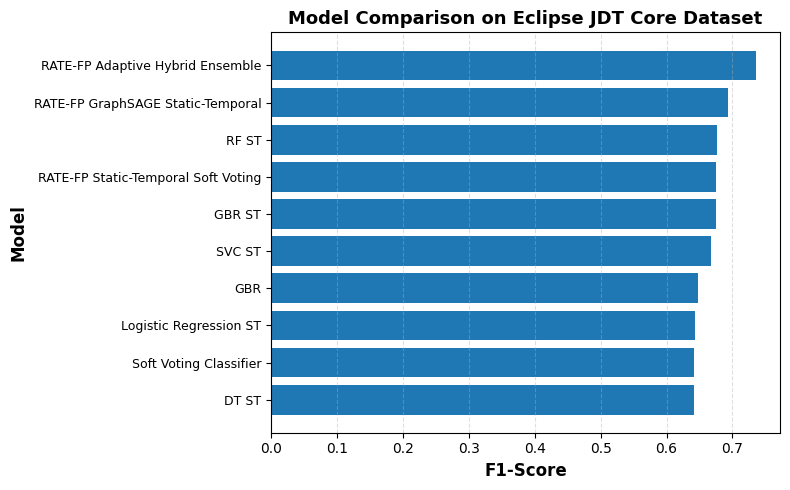

Saved F1 comparison figure to:
/content/drive/MyDrive/RATE_FP_Project/figures/Figure_F1_Model_Comparison_RATE_FP.tiff


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"

top_models = final_table.head(10).copy()
top_models = top_models.sort_values("F1", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(top_models["Model"], top_models["F1"])

plt.xlabel("F1-Score", fontsize=12, fontweight="bold")
plt.ylabel("Model", fontsize=12, fontweight="bold")
plt.title("Model Comparison on Eclipse JDT Core Dataset", fontsize=13, fontweight="bold")

plt.xticks(fontsize=10)
plt.yticks(fontsize=9)

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()

f1_fig_path = FIG_DIR / "Figure_F1_Model_Comparison_RATE_FP.tiff"
plt.savefig(f1_fig_path, dpi=600, format="tiff", bbox_inches="tight")
plt.show()

print("Saved F1 comparison figure to:")
print(f1_fig_path)

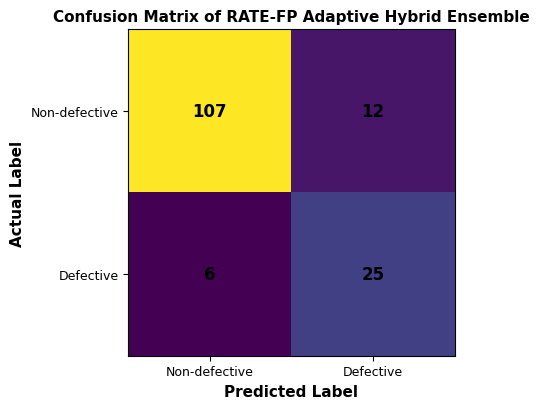

Saved confusion matrix figure to:
/content/drive/MyDrive/RATE_FP_Project/figures/Figure_Confusion_Matrix_RATE_FP.tiff


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cm = np.array([[107, 12],
               [6, 25]])

plt.figure(figsize=(4.8, 4.2))
plt.imshow(cm)

plt.title("Confusion Matrix of RATE-FP Adaptive Hybrid Ensemble", fontsize=11, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=11, fontweight="bold")
plt.ylabel("Actual Label", fontsize=11, fontweight="bold")

plt.xticks([0, 1], ["Non-defective", "Defective"], fontsize=9)
plt.yticks([0, 1], ["Non-defective", "Defective"], fontsize=9)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=12, fontweight="bold")

plt.tight_layout()

cm_fig_path = FIG_DIR / "Figure_Confusion_Matrix_RATE_FP.tiff"
plt.savefig(cm_fig_path, dpi=600, format="tiff", bbox_inches="tight")
plt.show()

print("Saved confusion matrix figure to:")
print(cm_fig_path)

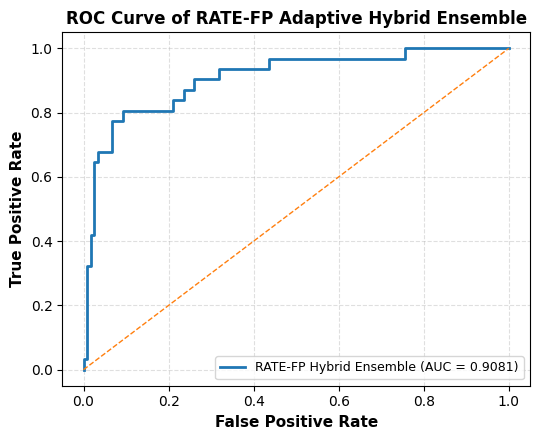

Saved ROC figure to:
/content/drive/MyDrive/RATE_FP_Project/figures/Figure_ROC_RATE_FP_Hybrid.tiff


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test_full, final_test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5.5, 4.5))
plt.plot(fpr, tpr, linewidth=2, label=f"RATE-FP Hybrid Ensemble (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.xlabel("False Positive Rate", fontsize=11, fontweight="bold")
plt.ylabel("True Positive Rate", fontsize=11, fontweight="bold")
plt.title("ROC Curve of RATE-FP Adaptive Hybrid Ensemble", fontsize=12, fontweight="bold")
plt.legend(loc="lower right", fontsize=9)
plt.grid(linestyle="--", alpha=0.4)
plt.tight_layout()

roc_fig_path = FIG_DIR / "Figure_ROC_RATE_FP_Hybrid.tiff"
plt.savefig(roc_fig_path, dpi=600, format="tiff", bbox_inches="tight")
plt.show()

print("Saved ROC figure to:")
print(roc_fig_path)

In [ ]:
import pandas as pd
import numpy as np

rf_model = base_models["RF_ST"]

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values("Importance", ascending=False)

display(importance_df.head(25))

importance_path = OUTPUT_DIR / "Table_RF_ST_Feature_Importance.csv"
importance_df.to_csv(importance_path, index=False)

print("Saved feature importance table to:")
print(importance_path)

,Feature,Importance
174,rfc_temp_change_count,0.032318
183,wmc_temp_change_count,0.027361
111,numberOfLinesOfCode_temp_change_count,0.023941
109,numberOfLinesOfCode_temp_last,0.022300
181,wmc_temp_last,0.020944
168,rfc_temp_std,0.020699
31,wmc,0.020450
107,numberOfLinesOfCode_temp_max,0.019046
177,wmc_temp_std,0.018596
180,wmc_temp_first,0.017569


Saved feature importance table to:
/content/drive/MyDrive/RATE_FP_Project/processed/Table_RF_ST_Feature_Importance.csv


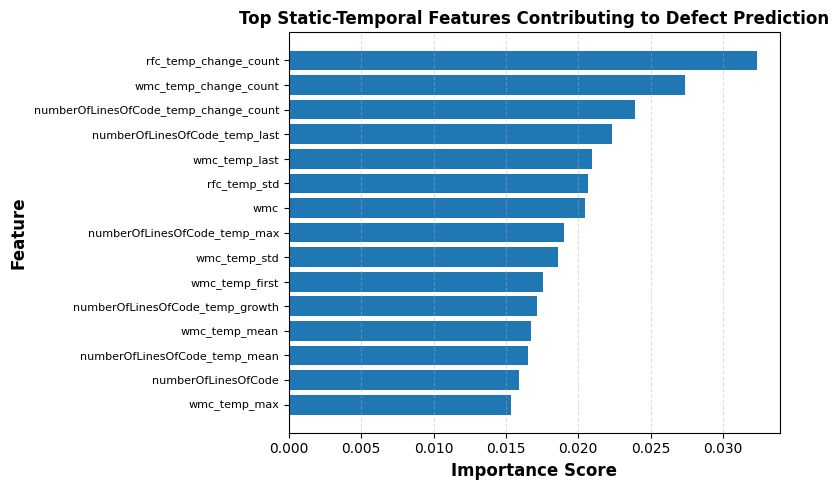

Saved feature importance figure to:
/content/drive/MyDrive/RATE_FP_Project/figures/Figure_Feature_Importance_RATE_FP.tiff


In [ ]:
import matplotlib.pyplot as plt

top_imp = importance_df.head(15).sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(top_imp["Feature"], top_imp["Importance"])

plt.xlabel("Importance Score", fontsize=12, fontweight="bold")
plt.ylabel("Feature", fontsize=12, fontweight="bold")
plt.title("Top Static-Temporal Features Contributing to Defect Prediction", fontsize=12, fontweight="bold")

plt.xticks(fontsize=10)
plt.yticks(fontsize=8)
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()

imp_fig_path = FIG_DIR / "Figure_Feature_Importance_RATE_FP.tiff"
plt.savefig(imp_fig_path, dpi=600, format="tiff", bbox_inches="tight")
plt.show()

print("Saved feature importance figure to:")
print(imp_fig_path)

In [ ]:
final_prediction_df = pd.DataFrame({
    "classname": rate_fp_df.iloc[test_idx]["classname"].values,
    "actual_label": y_test_full,
    "predicted_probability": final_test_prob,
    "predicted_label": final_test_pred
})

final_prediction_df["prediction_status"] = np.where(
    final_prediction_df["actual_label"] == final_prediction_df["predicted_label"],
    "Correct",
    "Incorrect"
)

display(final_prediction_df.head(20))

prediction_path = OUTPUT_DIR / "Table_RATE_FP_Final_Test_Predictions.csv"
final_prediction_df.to_csv(prediction_path, index=False)

print("Saved final prediction table to:")
print(prediction_path)

,classname,actual_label,predicted_probability,predicted_label,prediction_status
0,org::eclipse::jdt::core::jdom::DOMException,0,0.025684,0,Correct
1,org::eclipse::jdt::internal::core::dom::rewrit...,0,0.067841,0,Correct
2,org::eclipse::jdt::internal::core::JavaElement,1,0.876120,1,Correct
3,org::eclipse::jdt::internal::compiler::ClassFile,1,0.851561,1,Correct
4,org::eclipse::jdt::internal::core::builder::Cl...,0,0.170287,0,Correct
5,org::eclipse::jdt::internal::core::CreateTypeM...,1,0.243491,0,Incorrect
6,org::eclipse::jdt::internal::core::search::mat...,1,0.867683,1,Correct
7,org::eclipse::jdt::internal::core::PackageFrag...,0,0.340283,0,Correct
8,org::eclipse::jdt::internal::compiler::ast::Fo...,0,0.614014,1,Incorrect
9,org::eclipse::jdt::internal::compiler::lookup:...,1,0.869372,1,Correct


Saved final prediction table to:
/content/drive/MyDrive/RATE_FP_Project/processed/Table_RATE_FP_Final_Test_Predictions.csv
